In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
import os

# Load data
df = pd.read_csv('C:/Users/ELITE/Documents/AGROALERT/data_processed/master_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df_pred = pd.read_csv('C:/Users/ELITE/Documents/AGROALERT/data_processed/predictions.csv')
df_pred['date'] = pd.to_datetime(df_pred['date'])

OUTPUT = 'C:/Users/ELITE/Documents/AGROALERT/data_processed/'

# Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 200
})

COLORS = ['#c0392b','#e67e22','#f39c12','#27ae60','#2980b9',
          '#8e44ad','#16a085','#d35400','#2c3e50','#7f8c8d',
          '#e74c3c','#3498db','#1abc9c','#9b59b6','#e91e63']

print("Data loaded successfully!")
print(f"Master dataset: {df.shape}")
print(f"Communities: {df['community'].nunique()}")

Data loaded successfully!
Master dataset: (1575, 17)
Communities: 15


In [3]:
# ── FIGURE 1: NDVI Time Series (5 key communities) ──
fig, axes = plt.subplots(5, 1, figsize=(10, 12))
key_communities = ['Tamale', 'Ho', 'Kumasi', 'Bolgatanga', 'Techiman']
colors_ndvi = ['#c0392b', '#2980b9', '#8e44ad', '#27ae60', '#e67e22']

for i, (comm, col) in enumerate(zip(key_communities, colors_ndvi)):
    df_c = df[df['community'] == comm].sort_values('date')
    axes[i].plot(df_c['date'], df_c['ndvi'], color=col, linewidth=1.2)
    axes[i].axhline(y=0.2, color='red', linestyle='--', alpha=0.6, linewidth=0.8)
    axes[i].fill_between(df_c['date'], df_c['ndvi'], 0.2,
        where=(df_c['ndvi'] < 0.2), alpha=0.3, color='red', label='Stress zone')
    axes[i].set_ylabel('NDVI', fontsize=8)
    axes[i].set_ylim(0, 0.8)
    axes[i].set_title(f'{comm} Region', fontsize=9, fontweight='bold', color=col)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(labelsize=7)
    if i < 4:
        axes[i].set_xticklabels([])

fig.suptitle('Fig. 2. NDVI Vegetation Health Trends — Five Key Farming Communities (2022–2023)\n'
             'Red dashed line indicates vegetation stress threshold (NDVI = 0.2). '
             'Shaded areas represent stress periods.',
             fontsize=8.5, y=0.02, ha='center')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT + 'fig2_ndvi_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 2 saved!")

# ── FIGURE 2: Drought Risk Heatmap ──
fig, ax = plt.subplots(figsize=(12, 6))

communities_list = df_pred['community'].unique()
months = pd.date_range('2022-01', '2024-01', freq='M')
month_labels = [m.strftime('%b %Y') for m in months]

heatmap_data = np.zeros((len(communities_list), len(months)))
for i, comm in enumerate(communities_list):
    df_c = df_pred[df_pred['community'] == comm].copy()
    df_c['month'] = df_c['date'].dt.to_period('M')
    monthly = df_c.groupby('month')['ensemble_score'].mean()
    for j, m in enumerate(months):
        key = m.to_period('M')
        if key in monthly.index:
            heatmap_data[i, j] = monthly[key]

im = ax.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(month_labels)))
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(communities_list)))
ax.set_yticklabels(communities_list, fontsize=8)
ax.axhline(y=11.5, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Ensemble Drought Score', fontsize=8)
cbar.ax.axhline(y=0.65, color='black', linewidth=1.5)
cbar.ax.text(1.3, 0.65, 'Alert\nThreshold\n(0.65)',
             fontsize=6.5, va='center', transform=cbar.ax.transAxes)
ax.set_title('Fig. 3. Monthly Drought Risk Heatmap — All 15 Communities (2022–2023)\n'
             'Colour scale: green=low risk, red=high risk. Alert threshold = 0.65.',
             fontsize=9, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig3_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 3 saved!")

# ── FIGURE 3: Feature Importance ──
with open('C:/Users/ELITE/Documents/AGROALERT/src_model/rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)

features = ['community_enc','region_enc','ndvi','rainfall_mm',
            'temp_max','temp_min','humidity','et0',
            'lst_celsius','ndvi_anomaly','rainfall_deficit',
            'water_balance','spei_proxy']
feature_labels = ['Community','Region','NDVI','Rainfall',
                  'Temp Max','Temp Min','Humidity','ET\u2080',
                  'LST (\u00b0C)','NDVI Anomaly','Rainfall Deficit',
                  'Water Balance','SPEI Proxy']

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
colors_fi = ['#c0392b' if importances[i] > 0.15 else
             '#e67e22' if importances[i] > 0.05 else '#3498db'
             for i in sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh([feature_labels[i] for i in sorted_idx],
               importances[sorted_idx], color=colors_fi, edgecolor='white')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5, fontweight='bold')
ax.set_xlabel('Feature Importance Score (Mean Decrease in Impurity)', fontsize=8)
ax.set_title('Fig. 4. Random Forest Feature Importance\n'
             'NDVI Anomaly and SPEI Proxy are the strongest drought predictors.',
             fontsize=9)
ax.set_xlim(0, 0.45)
ax.grid(axis='x', alpha=0.2)

from matplotlib.patches import Patch
legend = [Patch(color='#c0392b', label='High importance (>0.15)'),
          Patch(color='#e67e22', label='Medium importance (0.05–0.15)'),
          Patch(color='#3498db', label='Lower importance (<0.05)')]
ax.legend(handles=legend, fontsize=7.5, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT + 'fig4_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 4 saved!")

# ── FIGURE 4: ROC Curve ──
le_c = LabelEncoder()
le_r = LabelEncoder()
df['community_enc'] = le_c.fit_transform(df['community'])
df['region_enc'] = le_r.fit_transform(df['region'])

X = df[features]
y = df['drought_label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#c0392b', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#c0392b')

idx_065 = np.argmin(np.abs(thresholds - 0.65))
ax.plot(fpr[idx_065], tpr[idx_065], 'ro', markersize=8,
        label=f'Alert threshold (0.65): TPR={tpr[idx_065]:.2f}')

ax.set_xlabel('False Positive Rate', fontsize=9)
ax.set_ylabel('True Positive Rate', fontsize=9)
ax.set_title('Fig. 5. ROC Curve — Random Forest Drought Classifier\n'
             f'AUC-ROC = {auc:.3f}. Red dot marks the ensemble alert threshold.',
             fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.savefig(OUTPUT + 'fig5_roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 5 saved!")

# ── FIGURE 5: Community Risk Bar Chart ──
risk_summary = df_pred.groupby('community')['ensemble_score'].max().sort_values(ascending=True)
colors_bar = ['#c0392b' if s >= 0.75 else '#f59e0b' if s >= 0.5 else '#27ae60'
              for s in risk_summary.values]
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(risk_summary.index, risk_summary.values,
               color=colors_bar, edgecolor='white', height=0.65)
ax.axvline(x=0.65, color='red', linestyle='--', lw=1.5,
           label='Alert threshold (0.65)', alpha=0.8)
for bar, val in zip(bars, risk_summary.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Maximum Ensemble Drought Score', fontsize=9)
ax.set_title('Fig. 6. Maximum Ensemble Drought Score — All 15 Communities\n'
             'Red = HIGH risk (≥0.75), Amber = MEDIUM (0.50–0.75), Green = LOW (<0.50)',
             fontsize=9)
ax.set_xlim(0, 1.08)
ax.grid(axis='x', alpha=0.2)
ax.legend(fontsize=8)

from matplotlib.patches import Patch
legend = [Patch(color='#c0392b', label='HIGH risk (\u22650.75)'),
          Patch(color='#f59e0b', label='MEDIUM risk (0.50\u20130.75)'),
          Patch(color='#27ae60', label='LOW risk (<0.50)')]
ax.legend(handles=legend, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT + 'fig6_community_risk.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 6 saved!")

# ── FIGURE 6: Rainfall vs NDVI Scatter ──
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(df['rainfall_mm'], df['ndvi'],
                c=df['drought_label'], cmap='RdYlGn',
                alpha=0.4, s=15, edgecolors='none')
axes[0].set_xlabel('Weekly Rainfall (mm)', fontsize=9)
axes[0].
set_ylabel('NDVI', fontsize=9)
axes[0].set_title('(a) Rainfall vs NDVI\n(red=drought, green=no drought)', fontsize=8.5)
axes[0].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
axes[0].grid(alpha=0.15)

axes[1].scatter(df['spei_proxy'], df['ndvi_anomaly'],
                c=df['drought_label'], cmap='RdYlGn',
                alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel('SPEI Proxy (Standardised Water Balance)', fontsize=9)
axes[1].set_ylabel('NDVI Anomaly', fontsize=9)
axes[1].set_title('(b) SPEI Proxy vs NDVI Anomaly\n(dual-condition drought labelling region shown)',
                  fontsize=8.5)
axes[1].axhline(y=-0.05, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axvline(x=-1.0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].fill_between([-4, -1.0], [-0.25, -0.25], [-0.05, -0.05],
                      alpha=0.08, color='red', label='Drought label zone')
axes[1].legend(fontsize=7.5)
axes[1].grid(alpha=0.15)

fig.suptitle('Fig. 7. Feature Relationships and Drought Label Distribution\n'
             'Left: raw satellite vs weather correlation. '
             'Right: dual-condition drought labelling boundary (SPEI<−1.0 AND NDVI anomaly<−0.05).',
             fontsize=8.5, y=0.0)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(OUTPUT + 'fig7_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 7 saved!")

print("\n=== ALL FIGURES SAVED ===")
print(f"Location: {OUTPUT}")
for i in range(2, 8):
    fname = f'fig{i}_*.png'
    import glob
    matches = glob.glob(OUTPUT + f'fig{i}_*.png')
    if matches:
        print(f"  ✅ Figure {i}: {matches[0].split('/')[-1]}")

SyntaxError: invalid syntax (59435721.py, line 183)

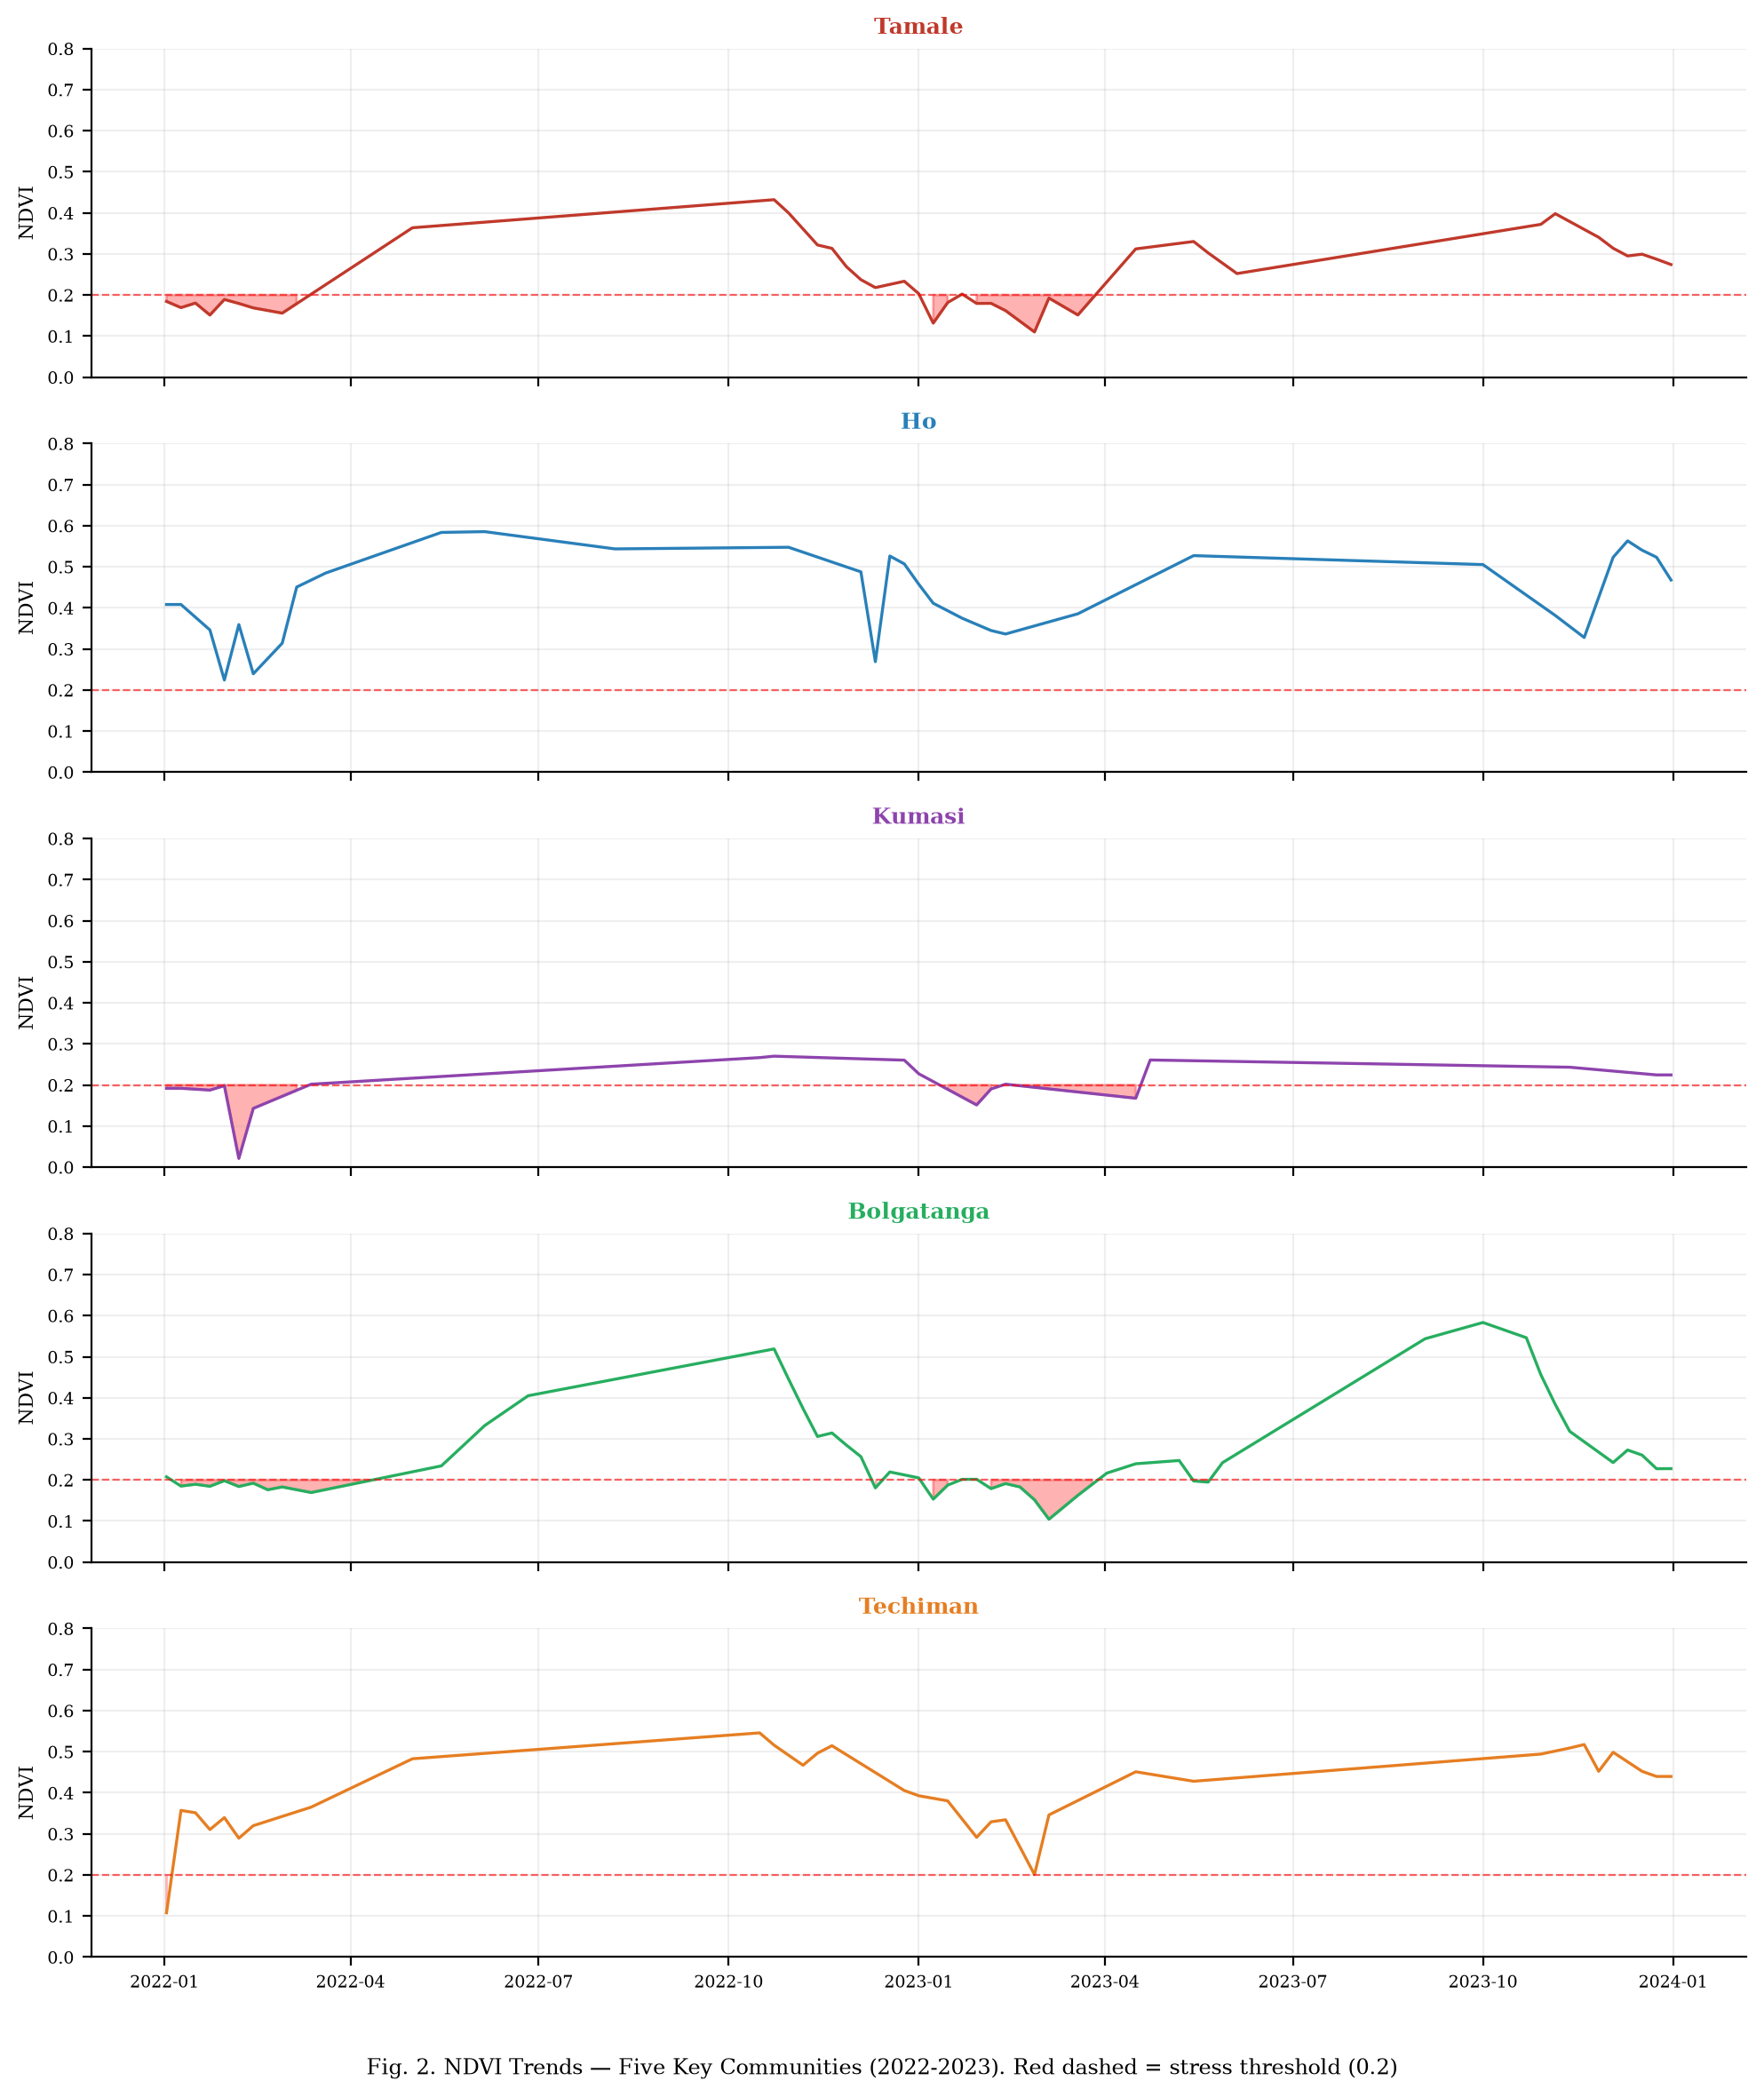

Fig 2 saved!


In [4]:
fig, axes = plt.subplots(5, 1, figsize=(10, 12))
key_communities = ['Tamale', 'Ho', 'Kumasi', 'Bolgatanga', 'Techiman']
colors_ndvi = ['#c0392b', '#2980b9', '#8e44ad', '#27ae60', '#e67e22']

for i, (comm, col) in enumerate(zip(key_communities, colors_ndvi)):
    df_c = df[df['community'] == comm].sort_values('date')
    axes[i].plot(df_c['date'], df_c['ndvi'], color=col, linewidth=1.2)
    axes[i].axhline(y=0.2, color='red', linestyle='--', alpha=0.6, linewidth=0.8)
    axes[i].fill_between(df_c['date'], df_c['ndvi'], 0.2,
        where=(df_c['ndvi'] < 0.2), alpha=0.3, color='red')
    axes[i].set_ylabel('NDVI', fontsize=8)
    axes[i].set_ylim(0, 0.8)
    axes[i].set_title(f'{comm}', fontsize=9, fontweight='bold', color=col)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(labelsize=7)
    if i < 4:
        axes[i].set_xticklabels([])

fig.suptitle('Fig. 2. NDVI Trends — Five Key Communities (2022-2023). Red dashed = stress threshold (0.2)',
             fontsize=8.5, y=0.01)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(OUTPUT + 'fig2_ndvi_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 2 saved!")

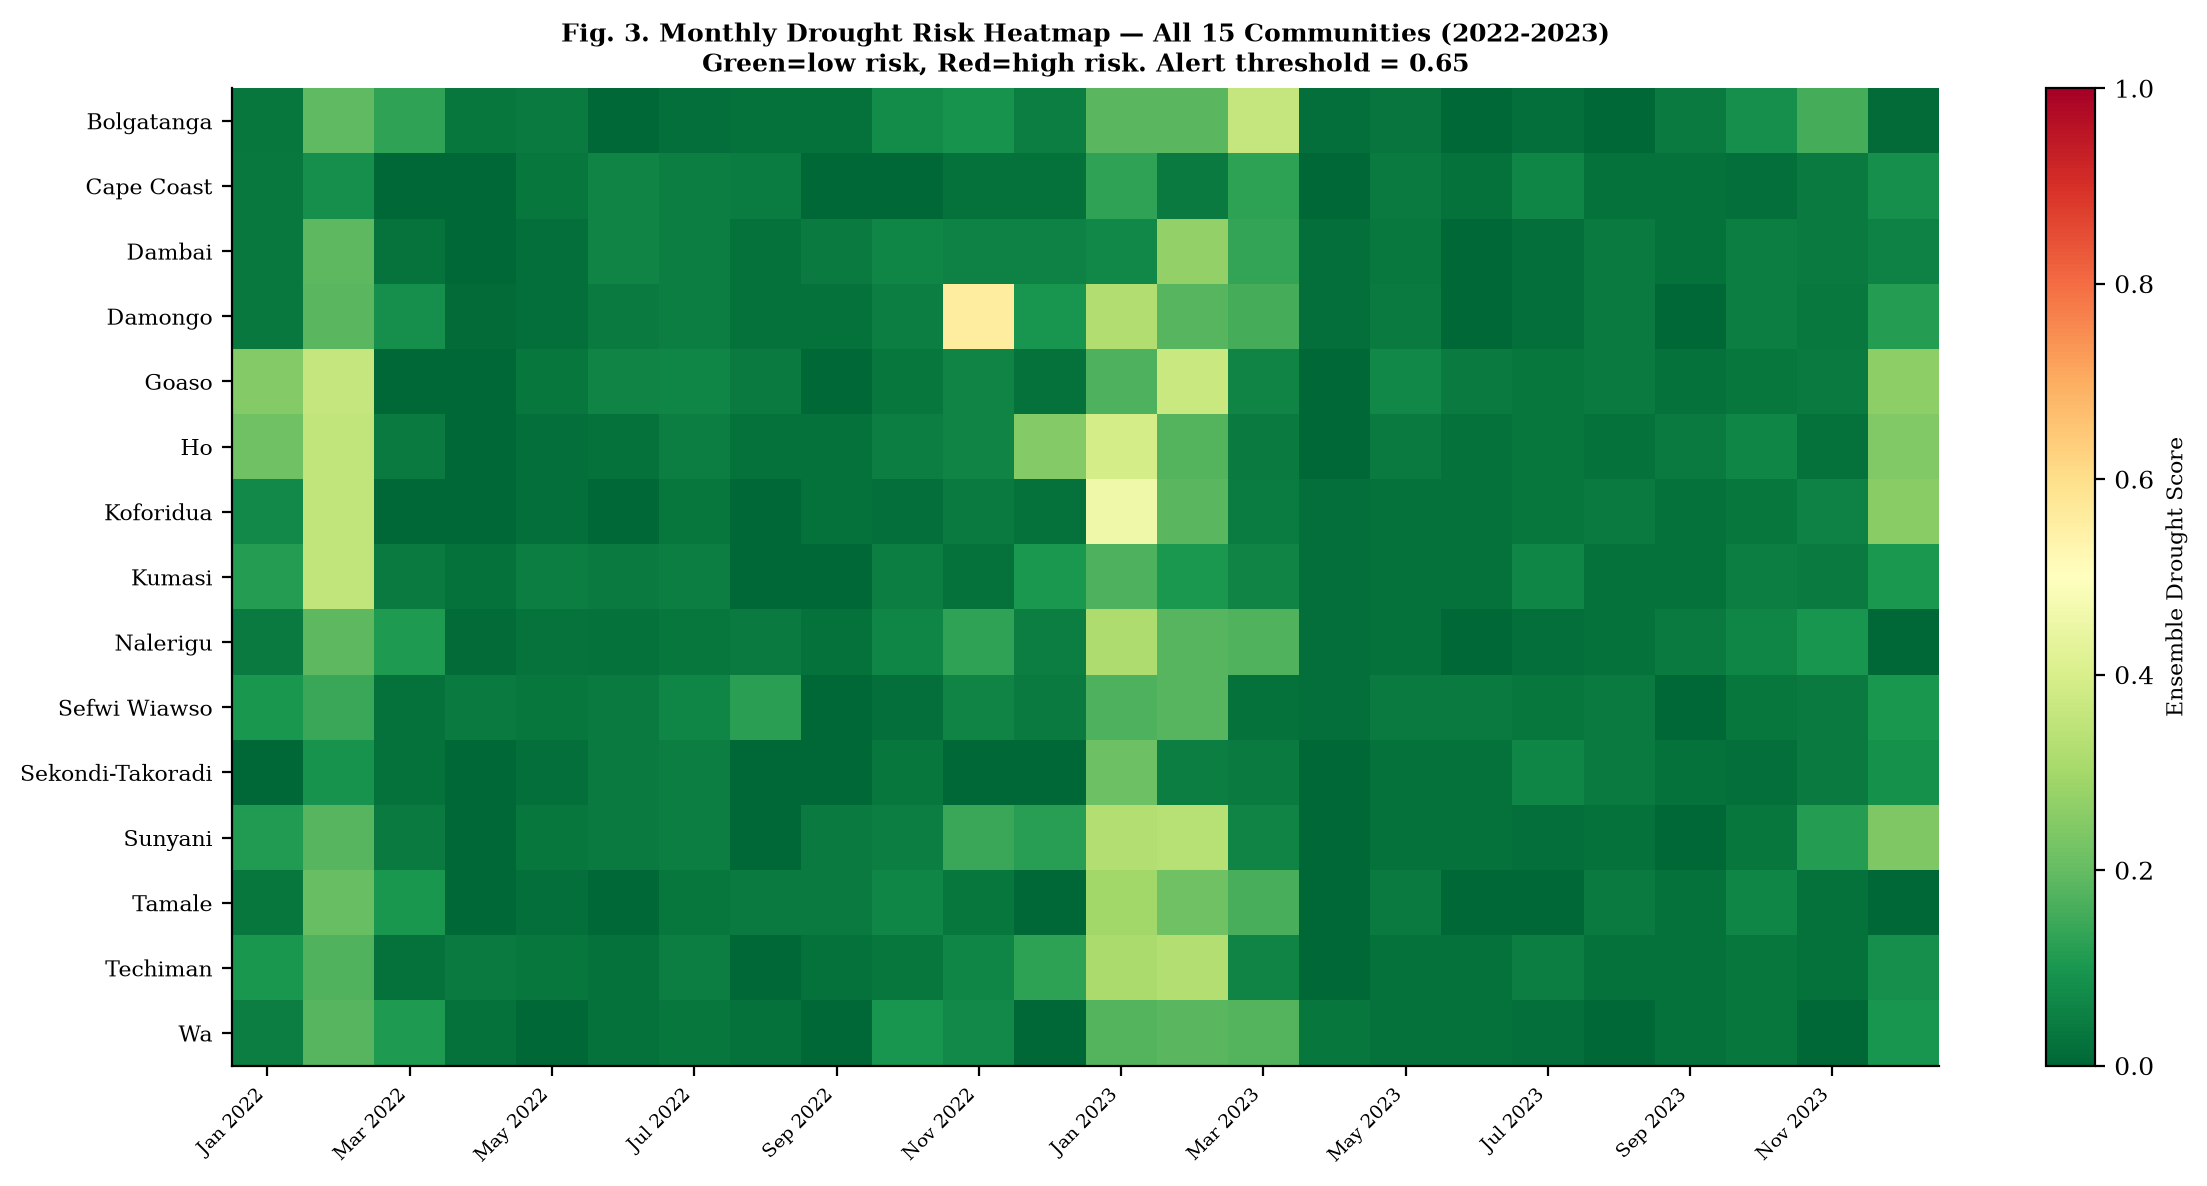

Fig 3 saved!


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
communities_list = sorted(df_pred['community'].unique())
months = pd.date_range('2022-01', '2024-01', freq='ME')

heatmap_data = np.zeros((len(communities_list), len(months)))
for i, comm in enumerate(communities_list):
    df_c = df_pred[df_pred['community'] == comm].copy()
    df_c['month'] = df_c['date'].dt.to_period('M')
    monthly = df_c.groupby('month')['ensemble_score'].mean()
    for j, m in enumerate(months):
        key = m.to_period('M')
        if key in monthly.index:
            heatmap_data[i, j] = monthly[key]

im = ax.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
month_labels = [m.strftime('%b %Y') for m in months]
ax.set_xticks(range(0, len(month_labels), 2))
ax.set_xticklabels(month_labels[::2], rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(communities_list)))
ax.set_yticklabels(communities_list, fontsize=8)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Ensemble Drought Score', fontsize=8)
ax.set_title('Fig. 3. Monthly Drought Risk Heatmap — All 15 Communities (2022-2023)\nGreen=low risk, Red=high risk. Alert threshold = 0.65', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig3_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 3 saved!")

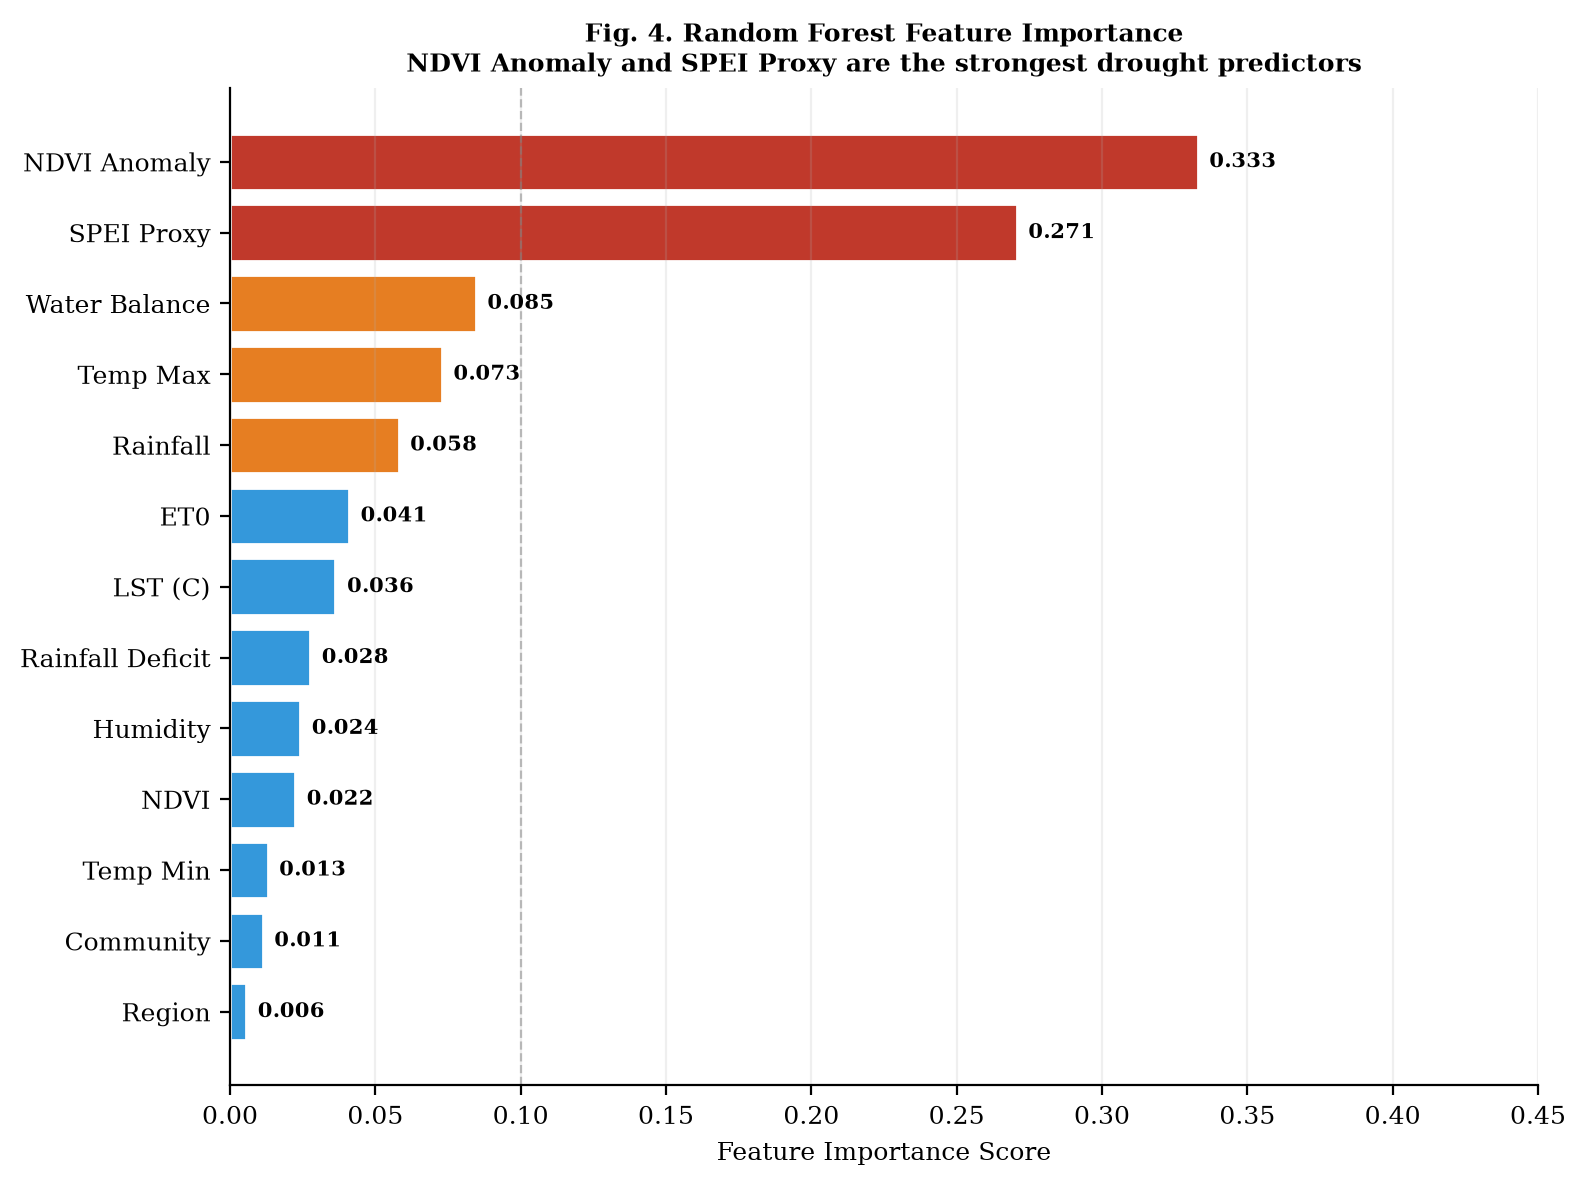

Fig 4 saved!


In [7]:
with open('C:/Users/ELITE/Documents/AGROALERT/src_model/rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)

features = ['community_enc','region_enc','ndvi','rainfall_mm',
            'temp_max','temp_min','humidity','et0',
            'lst_celsius','ndvi_anomaly','rainfall_deficit',
            'water_balance','spei_proxy']
feature_labels = ['Community','Region','NDVI','Rainfall',
                  'Temp Max','Temp Min','Humidity','ET0',
                  'LST (C)','NDVI Anomaly','Rainfall Deficit',
                  'Water Balance','SPEI Proxy']

importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
colors_fi = ['#c0392b' if importances[i] > 0.15 else
             '#e67e22' if importances[i] > 0.05 else '#3498db'
             for i in sorted_idx]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh([feature_labels[i] for i in sorted_idx],
               importances[sorted_idx], color=colors_fi, edgecolor='white')
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7.5, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=9)
ax.set_title('Fig. 4. Random Forest Feature Importance\nNDVI Anomaly and SPEI Proxy are the strongest drought predictors', fontsize=9)
ax.set_xlim(0, 0.45)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig4_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 4 saved!")

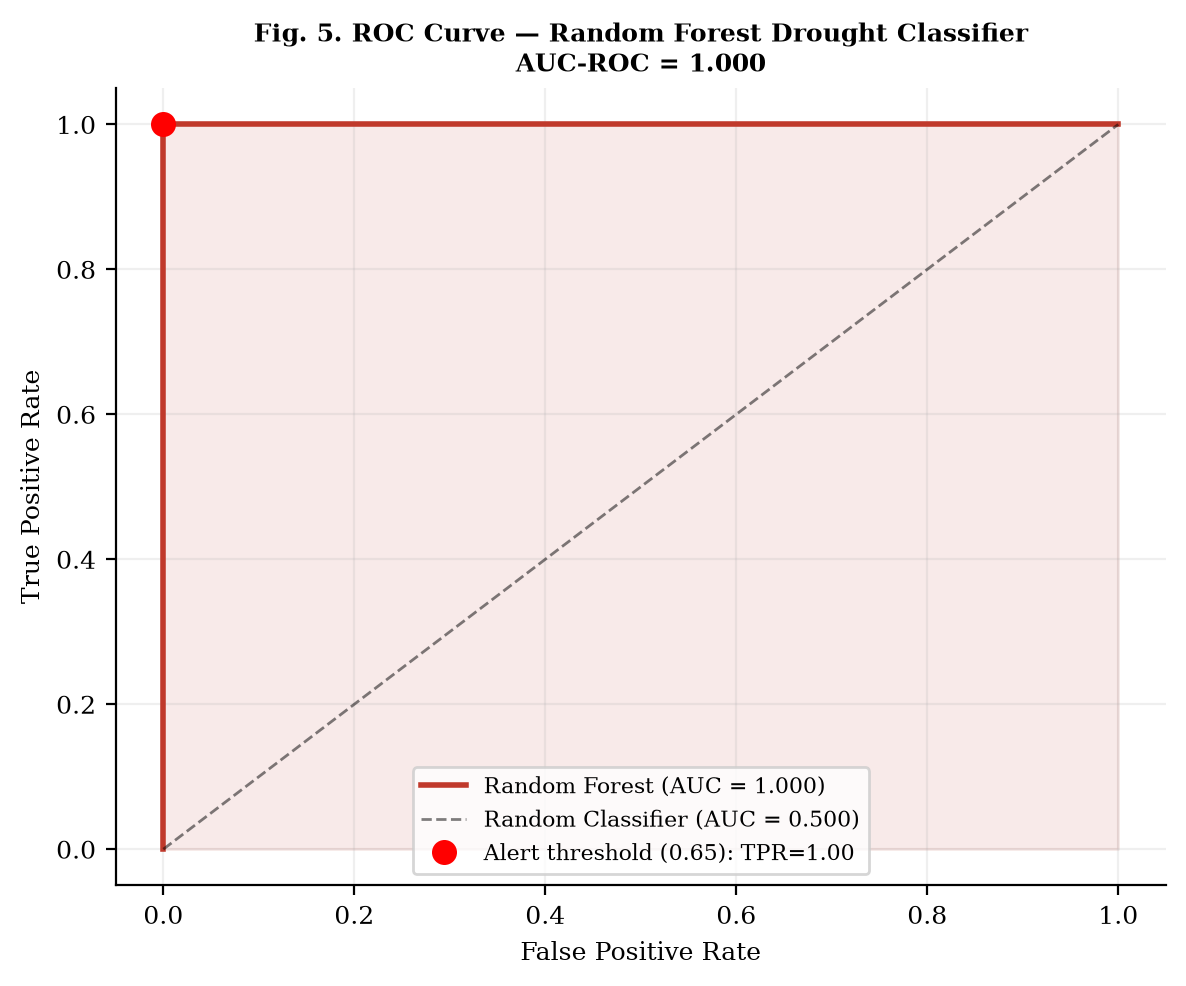

Fig 5 saved!


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le_c = LabelEncoder()
le_r = LabelEncoder()
df['community_enc'] = le_c.fit_transform(df['community'])
df['region_enc'] = le_r.fit_transform(df['region'])

X = df[features]
y = df['drought_label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#c0392b', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#c0392b')
idx = np.argmin(np.abs(thresholds - 0.65))
ax.plot(fpr[idx], tpr[idx], 'ro', markersize=8,
        label=f'Alert threshold (0.65): TPR={tpr[idx]:.2f}')
ax.set_xlabel('False Positive Rate', fontsize=9)
ax.set_ylabel('True Positive Rate', fontsize=9)
ax.set_title(f'Fig. 5. ROC Curve — Random Forest Drought Classifier\nAUC-ROC = {auc:.3f}', fontsize=9)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig5_roc_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 5 saved!")

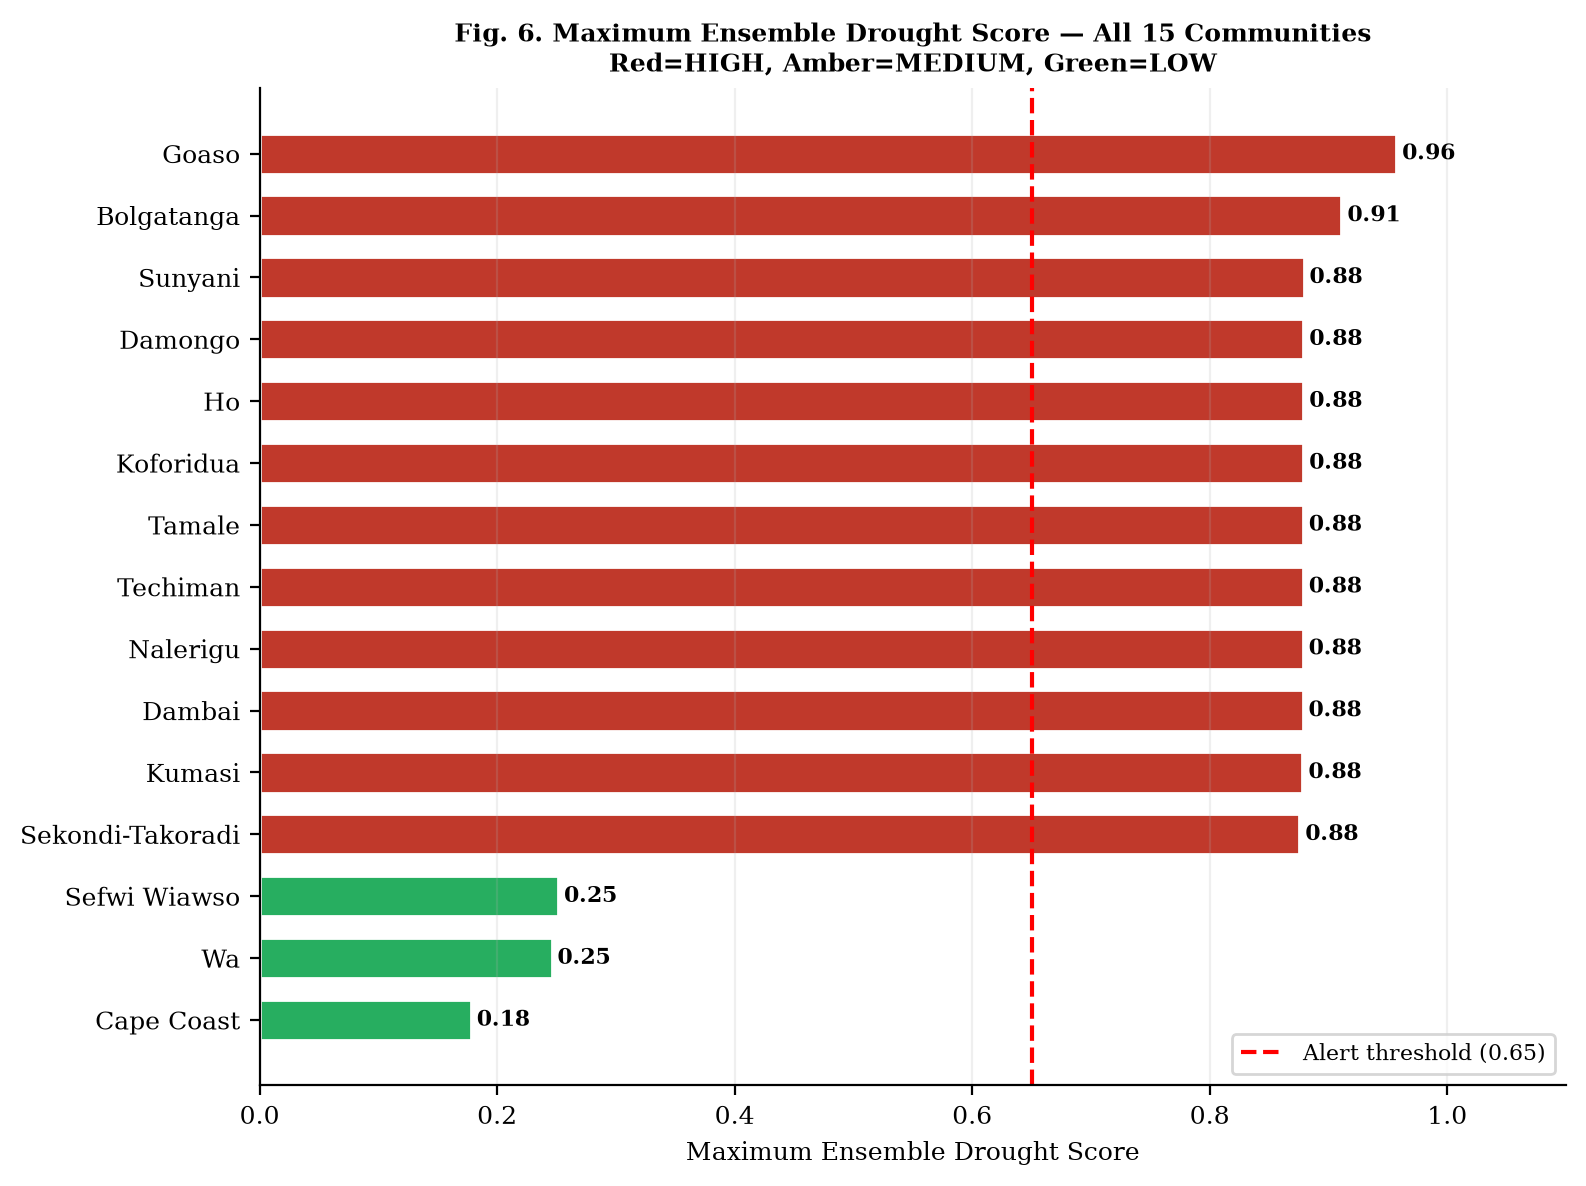

Fig 6 saved!


In [9]:
risk_summary = df_pred.groupby('community')['ensemble_score'].max().sort_values(ascending=True)
colors_bar = ['#c0392b' if s >= 0.75 else '#f59e0b' if s >= 0.5 else '#27ae60'
              for s in risk_summary.values]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(risk_summary.index, risk_summary.values,
               color=colors_bar, edgecolor='white', height=0.65)
ax.axvline(x=0.65, color='red', linestyle='--', lw=1.5, label='Alert threshold (0.65)')
for bar, val in zip(bars, risk_summary.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Maximum Ensemble Drought Score', fontsize=9)
ax.set_title('Fig. 6. Maximum Ensemble Drought Score — All 15 Communities\nRed=HIGH, Amber=MEDIUM, Green=LOW', fontsize=9)
ax.set_xlim(0, 1.1)
ax.grid(axis='x', alpha=0.2)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig6_community_risk.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 6 saved!")

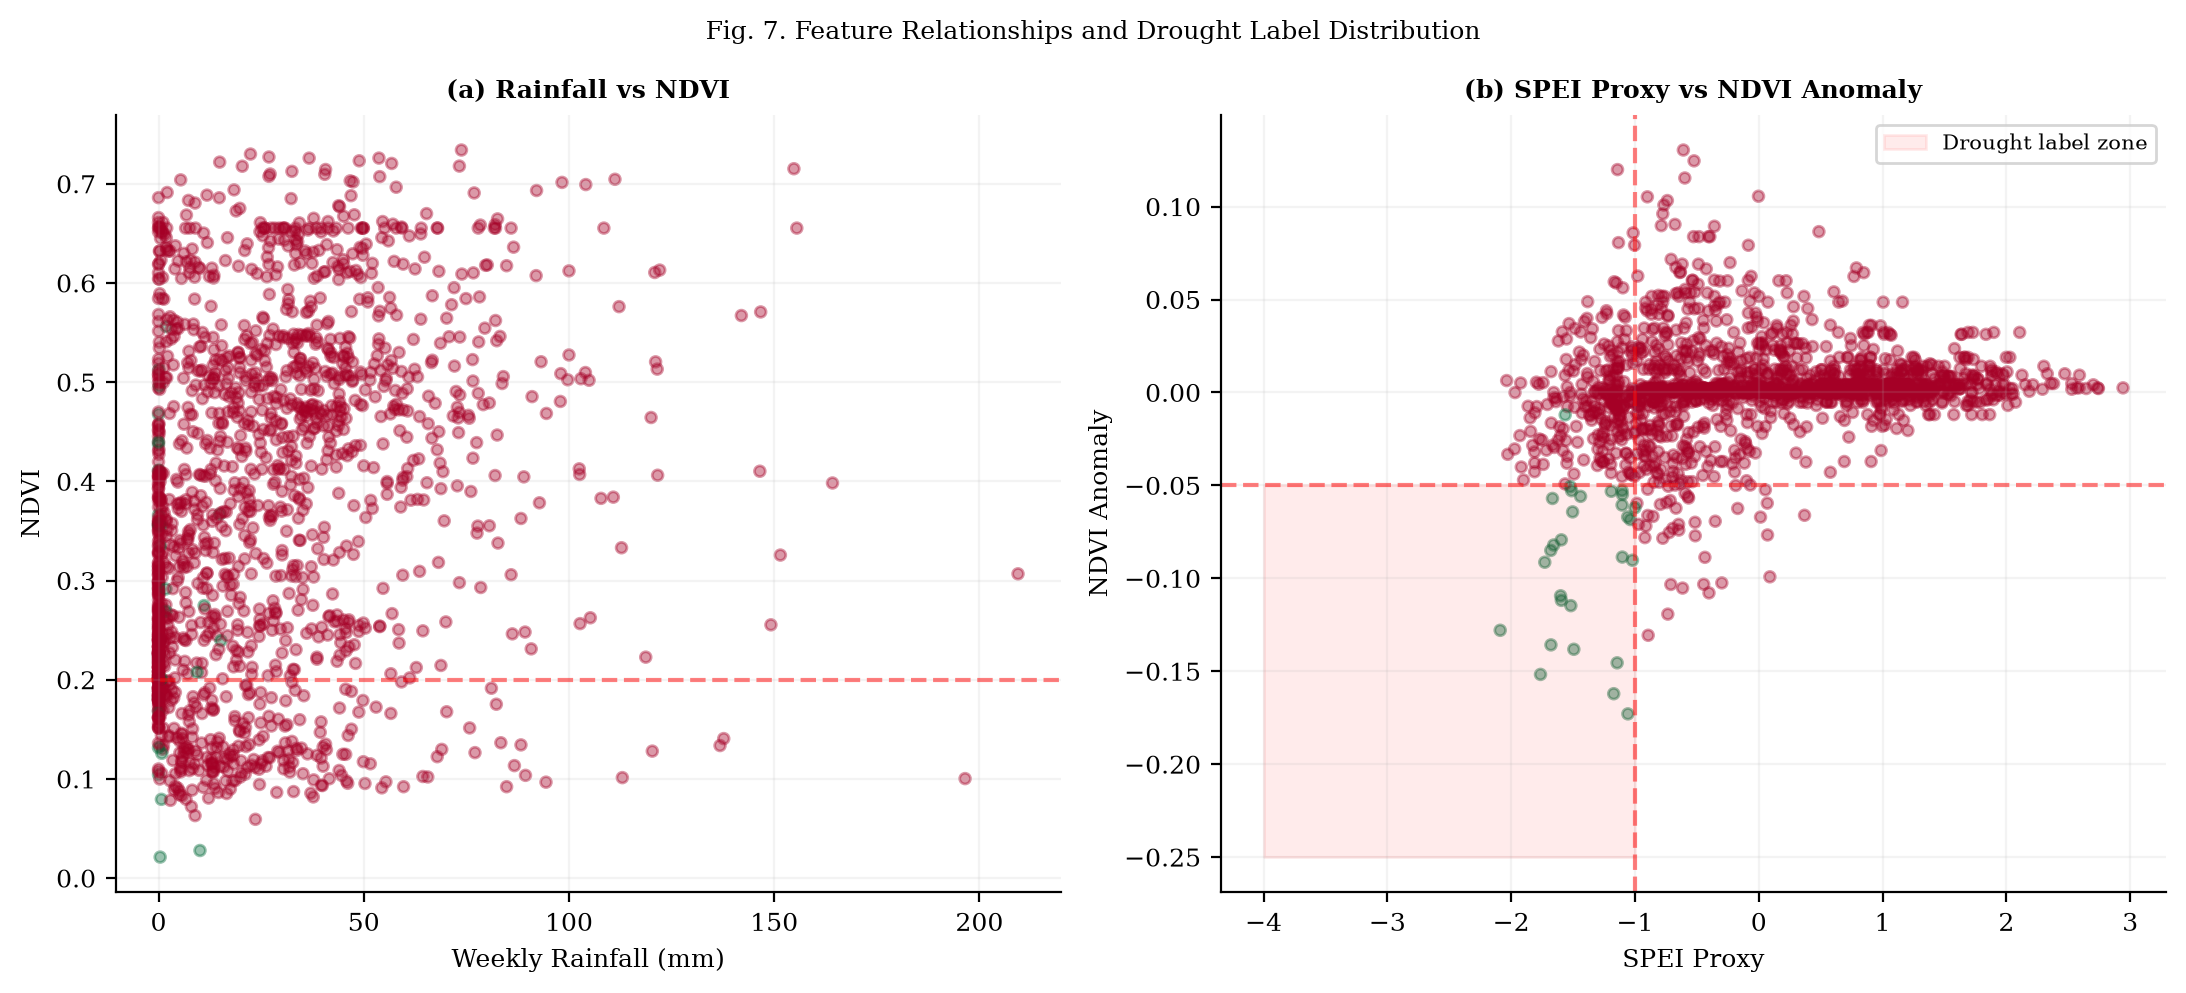

Fig 7 saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sc1 = axes[0].scatter(df['rainfall_mm'], df['ndvi'],
    c=df['drought_label'], cmap='RdYlGn', alpha=0.4, s=15)
axes[0].set_xlabel('Weekly Rainfall (mm)', fontsize=9)
axes[0].set_ylabel('NDVI', fontsize=9)
axes[0].set_title('(a) Rainfall vs NDVI', fontsize=9)
axes[0].axhline(y=0.2, color='red', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.15)

sc2 = axes[1].scatter(df['spei_proxy'], df['ndvi_anomaly'],
    c=df['drought_label'], cmap='RdYlGn', alpha=0.4, s=15)
axes[1].set_xlabel('SPEI Proxy', fontsize=9)
axes[1].set_ylabel('NDVI Anomaly', fontsize=9)
axes[1].set_title('(b) SPEI Proxy vs NDVI Anomaly', fontsize=9)
axes[1].axhline(y=-0.05, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=-1.0, color='red', linestyle='--', alpha=0.5)
axes[1].fill_between([-4,-1.0],[-0.25,-0.25],[-0.05,-0.05],
    alpha=0.08, color='red', label='Drought label zone')
axes[1].legend(fontsize=7.5)
axes[1].grid(alpha=0.15)

fig.suptitle('Fig. 7. Feature Relationships and Drought Label Distribution', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT + 'fig7_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print("Fig 7 saved!")